# Trio 1 VaR and CVaR Analysis

This notebook studies 5% VaR and CVaR for NIFTY 50, HUL, and Adani Enterprises.

VaR gives the tail-loss threshold. CVaR gives the average loss beyond that threshold. This trio is chosen to compare diversified index risk, stable-stock risk, and volatile-stock risk.

## Imports and settings

The notebook uses only the basic libraries needed for loading data, calculating returns, and plotting the risk measures.

In [60]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from risk_metrics import (
    historical_var,
    historical_cvar,
    parametric_var,
    parametric_cvar,
)

ALPHA = 0.05
DATA_DIR = Path("datasets") / "trio1"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.5f}".format)

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

## Load and inspect datasets

The files may have small schema differences, so the helper functions inspect columns first and then choose the date and close-price columns.

In [61]:
asset_files = {
    "NIFTY 50": DATA_DIR / "nifty50_2years.xlsx",
    "HUL": DATA_DIR / "hul_2years.xlsx",
    "Adani Enterprises": DATA_DIR / "adani_enterprises_2years.xlsx",
}


def read_excel_safely(path):
    df = pd.read_excel(path)

    # Some exports have an empty header row. Re-read without headers and assign simple names.
    unnamed = [str(col).lower().startswith("unnamed") for col in df.columns]
    if sum(unnamed) >= max(1, len(df.columns) - 1):
        df = pd.read_excel(path, header=None)
        df = df.dropna(how="all").reset_index(drop=True)

        if df.shape[1] == 7:
            df.columns = ["Date", "Adj Close", "Close", "High", "Low", "Open", "Volume"]
        elif df.shape[1] == 6:
            df.columns = ["Date", "Open", "High", "Low", "Close", "Volume"]
        else:
            df.columns = ["Date"] + [f"Column_{i}" for i in range(1, df.shape[1])]

    df.columns = [str(col).strip() for col in df.columns]
    return df


raw_data = {}

for asset, path in asset_files.items():
    df = read_excel_safely(path)
    raw_data[asset] = df

    print(f"\n{asset}")
    print("Path:", path)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head())


NIFTY 50
Path: datasets/trio1/nifty50_2years.xlsx
Shape: (493, 7)
Columns: ['Date', 'Adj Close_^NSEI', 'Close_^NSEI', 'High_^NSEI', 'Low_^NSEI', 'Open_^NSEI', 'Volume_^NSEI']


,Date,Adj Close_^NSEI,Close_^NSEI,High_^NSEI,Low_^NSEI,Open_^NSEI,Volume_^NSEI
0,2024-04-19,22147.00000,22147.00000,22179.55078,21777.65039,21861.50000,362500
1,2024-04-22,22336.40039,22336.40039,22375.65039,22198.15039,22336.90039,279300
2,2024-04-23,22368.00000,22368.00000,22447.55078,22349.44922,22447.05078,231500
3,2024-04-24,22402.40039,22402.40039,22476.44922,22384.00000,22421.55078,235900
4,2024-04-25,22570.34961,22570.34961,22625.94922,22305.25000,22316.90039,475000



HUL
Path: datasets/trio1/hul_2years.xlsx
Shape: (494, 7)
Columns: ['Date', 'Adj Close_HINDUNILVR.NS', 'Close_HINDUNILVR.NS', 'High_HINDUNILVR.NS', 'Low_HINDUNILVR.NS', 'Open_HINDUNILVR.NS', 'Volume_HINDUNILVR.NS']


,Date,Adj Close_HINDUNILVR.NS,Close_HINDUNILVR.NS,High_HINDUNILVR.NS,Low_HINDUNILVR.NS,Open_HINDUNILVR.NS,Volume_HINDUNILVR.NS
0,2024-04-19,2145.05103,2231.60010,2243.75000,2196.00000,2220.00000,2337694
1,2024-04-22,2154.56714,2241.50000,2253.55005,2229.05005,2250.00000,1804108
2,2024-04-23,2174.99268,2262.75000,2273.50000,2248.69995,2253.00000,1991778
3,2024-04-24,2172.59009,2260.25000,2268.35010,2245.64990,2266.05005,1404398
4,2024-04-25,2144.33032,2230.85010,2239.85010,2215.10010,2238.05005,4951866



Adani Enterprises
Path: datasets/trio1/adani_enterprises_2years.xlsx
Shape: (494, 7)
Columns: ['Date', 'Adj Close_ADANIENT.NS', 'Close_ADANIENT.NS', 'High_ADANIENT.NS', 'Low_ADANIENT.NS', 'Open_ADANIENT.NS', 'Volume_ADANIENT.NS']


,Date,Adj Close_ADANIENT.NS,Close_ADANIENT.NS,High_ADANIENT.NS,Low_ADANIENT.NS,Open_ADANIENT.NS,Volume_ADANIENT.NS
0,2024-04-19,3024.26782,3026.94995,3057.05005,2962.50000,3000.00000,1727317
1,2024-04-22,3060.63574,3063.35010,3077.50000,3025.00000,3053.00000,993929
2,2024-04-23,3062.38403,3065.10010,3091.00000,3043.10010,3059.00000,1654272
3,2024-04-24,3040.85303,3043.55005,3087.85010,3040.00000,3071.94995,605917
4,2024-04-25,3112.48926,3115.25000,3120.89990,3025.64990,3050.00000,1515529


## Cleaning and return calculation

For each asset, the notebook parses dates, sorts observations from oldest to newest, removes duplicate dates, keeps the selected price, and computes daily log returns.

In [62]:
def clean_name(name):
    return str(name).strip().lower().replace("_", " ").replace("-", " ")


def parse_dates(series):
    numeric = pd.to_numeric(series, errors="coerce")
    numeric_share = numeric.notna().mean()

    # Excel serial dates usually sit around 40,000-50,000 for current market data.
    if numeric_share > 0.8 and numeric.dropna().between(20000, 60000).mean() > 0.8:
        return pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")

    return pd.to_datetime(series, errors="coerce", dayfirst=True)


def detect_date_column(df):
    for col in df.columns:
        if "date" in clean_name(col):
            return col

    scores = {}
    for col in df.columns:
        scores[col] = parse_dates(df[col]).notna().mean()

    best_col = max(scores, key=scores.get)
    if scores[best_col] < 0.6:
        raise ValueError("Could not detect a reliable date column.")
    return best_col


def detect_price_column(df, date_col):
    candidates = [col for col in df.columns if col != date_col]
    names = {col: clean_name(col) for col in candidates}

    # Adjusted close is usually best for return analysis if it exists.
    preferred = [
        "adj close", "adjusted close", "close", "closing price",
        "price", "ltp", "last price", "last"
    ]

    for target in preferred:
        for col, name in names.items():
            if name == target:
                return col

    for target in preferred:
        for col, name in names.items():
            if target in name:
                return col

    numeric_cols = []
    for col in candidates:
        numeric_share = pd.to_numeric(df[col], errors="coerce").notna().mean()
        if numeric_share > 0.8:
            numeric_cols.append(col)

    if not numeric_cols:
        raise ValueError("Could not detect a reliable price column.")

    # If no names are useful, OHLC exports usually have close as one of the first prices.
    return numeric_cols[0]


def prepare_asset(df, asset_name):
    date_col = detect_date_column(df)
    price_col = detect_price_column(df, date_col)

    print(f"{asset_name}: selected date column = '{date_col}', price column = '{price_col}'")

    cleaned = pd.DataFrame({
        "Date": parse_dates(df[date_col]),
        "Price": pd.to_numeric(df[price_col], errors="coerce"),
    })

    before = len(cleaned)
    cleaned = cleaned.dropna(subset=["Date", "Price"])
    cleaned = cleaned.drop_duplicates(subset="Date", keep="last")
    cleaned = cleaned.sort_values("Date").reset_index(drop=True)
    cleaned["Log Return"] = np.log(cleaned["Price"] / cleaned["Price"].shift(1))
    cleaned = cleaned.dropna(subset=["Log Return"]).reset_index(drop=True)

    print(f"{asset_name}: rows before cleaning = {before}, rows after returns = {len(cleaned)}")
    return cleaned


cleaned_data = {}
returns = {}

for asset, df in raw_data.items():
    cleaned = prepare_asset(df, asset)
    cleaned_data[asset] = cleaned
    returns[asset] = cleaned["Log Return"]
    display(cleaned.head())

NIFTY 50: selected date column = 'Date', price column = 'Adj Close_^NSEI'
NIFTY 50: rows before cleaning = 493, rows after returns = 492


,Date,Price,Log Return
0,2024-04-22,22336.40039,0.00852
1,2024-04-23,22368.00000,0.00141
2,2024-04-24,22402.40039,0.00154
3,2024-04-25,22570.34961,0.00747
4,2024-04-26,22419.94922,-0.00669


HUL: selected date column = 'Date', price column = 'Adj Close_HINDUNILVR.NS'
HUL: rows before cleaning = 494, rows after returns = 493


,Date,Price,Log Return
0,2024-04-22,2154.56714,0.00443
1,2024-04-23,2174.99268,0.00944
2,2024-04-24,2172.59009,-0.00111
3,2024-04-25,2144.33032,-0.01309
4,2024-04-26,2136.44800,-0.00368


Adani Enterprises: selected date column = 'Date', price column = 'Adj Close_ADANIENT.NS'
Adani Enterprises: rows before cleaning = 494, rows after returns = 493


,Date,Price,Log Return
0,2024-04-22,3060.63574,0.01195
1,2024-04-23,3062.38403,0.00057
2,2024-04-24,3040.85303,-0.00706
3,2024-04-25,3112.48926,0.02328
4,2024-04-26,3077.67017,-0.01125


## Baseline descriptive metrics

These summary statistics give a first view of average return, volatility, and distribution shape before the tail-risk calculations.

In [63]:
descriptive_rows = []

for asset, r in returns.items():
    descriptive_rows.append({
        "Asset": asset,
        "Number of Observations": int(r.count()),
        "Mean Return": r.mean(),
        "Std Dev": r.std(ddof=1),
        "Minimum Return": r.min(),
        "Maximum Return": r.max(),
        "Skewness": r.skew(),
        "Kurtosis": r.kurtosis(),
    })

descriptive_table = pd.DataFrame(descriptive_rows).set_index("Asset")
descriptive_table.style.format({
    "Mean Return": "{:.5f}",
    "Std Dev": "{:.5f}",
    "Minimum Return": "{:.5f}",
    "Maximum Return": "{:.5f}",
    "Skewness": "{:.3f}",
    "Kurtosis": "{:.3f}",
})

,Number of Observations,Mean Return,Std Dev,Minimum Return,Maximum Return,Skewness,Kurtosis
Asset,,,,,,,
NIFTY 50,492,0.00019,0.00895,-0.06112,0.03747,-0.468,6.336
HUL,493,0.00009,0.01276,-0.05973,0.05789,0.113,3.380
Adani Enterprises,493,-0.00063,0.02639,-0.25627,0.10885,-2.516,27.493


### Baseline visual checks

These two plots make the return distribution and shape statistics easier to compare before moving to VaR and CVaR.

/var/folders/r4/6gw7r2mj0t5g7qss7k7160940000gn/T/ipykernel_72632/3644207391.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(return_values, labels=list(asset_files.keys()), showfliers=True)


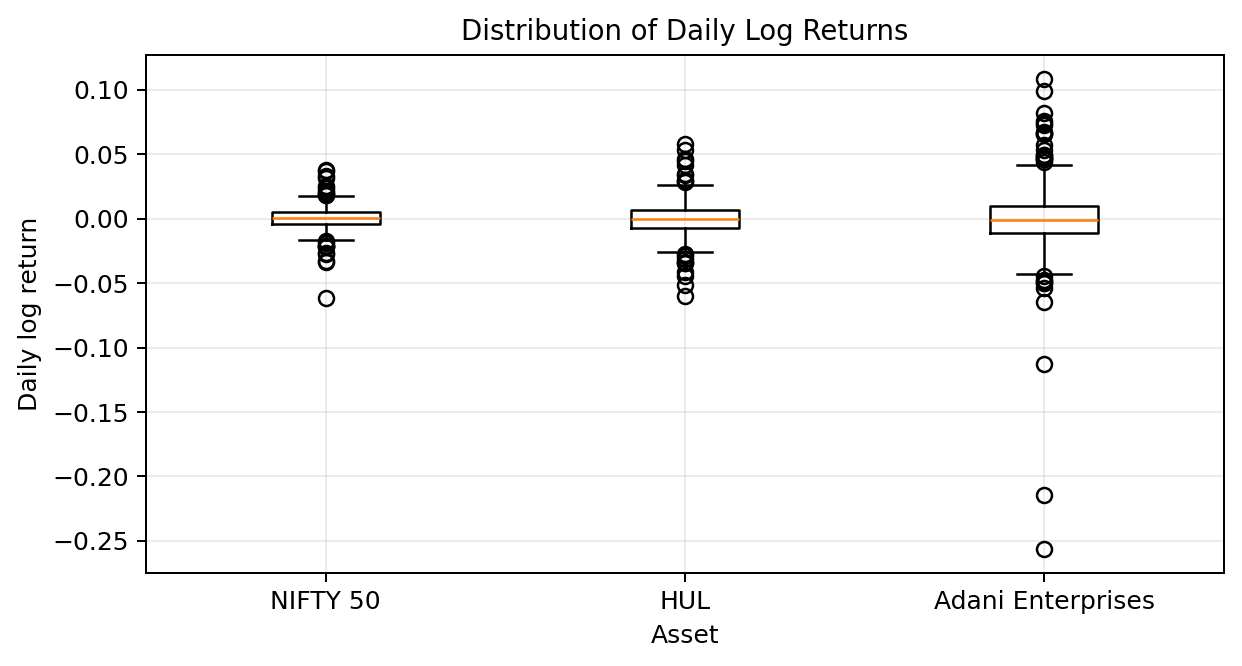

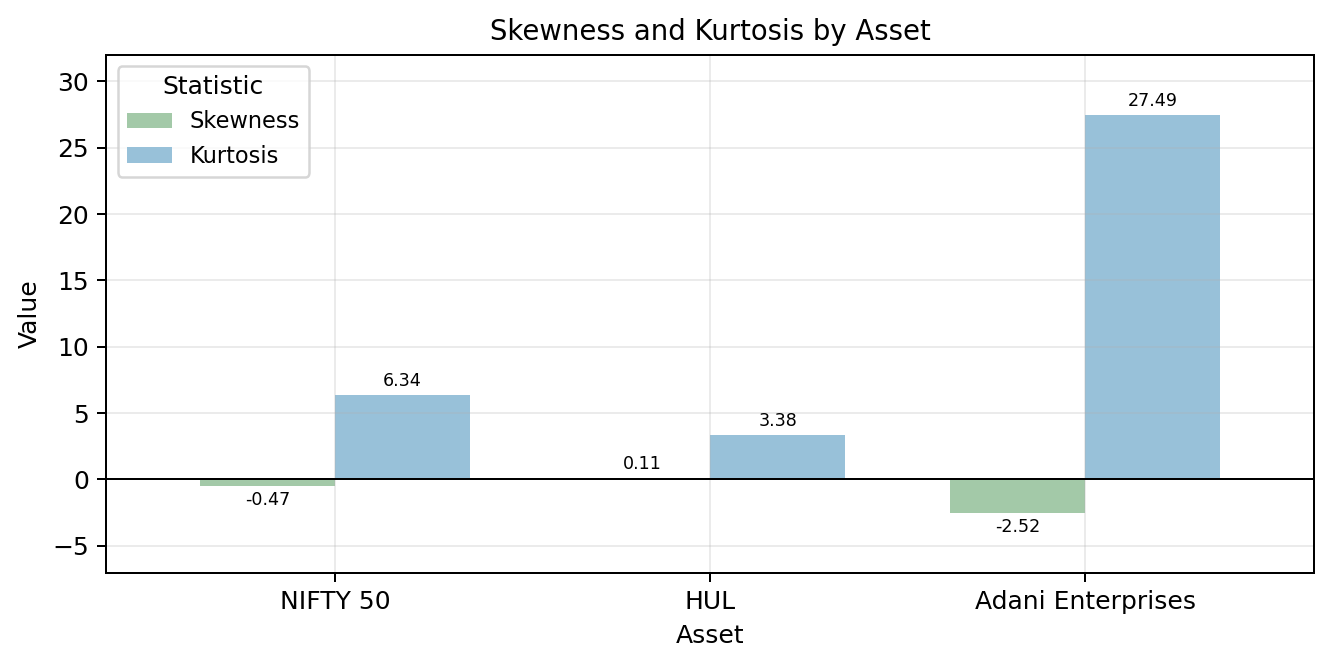

In [64]:
risk_color = [ "#A3C9A8", "#98C1D9"]

fig, ax = plt.subplots(figsize=(7, 3.8), dpi=180)
return_values = [returns[asset].dropna().values for asset in asset_files.keys()]
ax.boxplot(return_values, labels=list(asset_files.keys()), showfliers=True)
ax.set_title("Distribution of Daily Log Returns")
ax.set_xlabel("Asset")
ax.set_ylabel("Daily log return")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

shape_cols = ["Skewness", "Kurtosis"]
ax = descriptive_table[shape_cols].plot(kind="bar", figsize=(7.5, 3.8), width=0.72, color= risk_color)
ax.set_title("Skewness and Kurtosis by Asset")
ax.set_xlabel("Asset")
ax.set_ylabel("Value")
ax.legend(title="Statistic")
ax.axhline(0, color="black", linewidth=0.8)

for container in ax.containers:
    labels = [f"{value:.2f}" for value in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2, fontsize=7)

ax.margins(y=0.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Skewness
Skewness measures the **asymmetry** of a distribution around its mean.

$$
\text{Skewness} = \frac{\mathbb{E}\left[(X-\mu)^3\right]}{\sigma^3}
$$

where $\mu$ is the mean and $\sigma$ is the standard deviation.

- $\text{Skewness} > 0$: right-skewed distribution with a longer right tail  
- $\text{Skewness} < 0$: left-skewed distribution with a longer left tail  
- $\text{Skewness} = 0$: symmetric distribution  

### Kurtosis
Kurtosis measures the **heaviness of the tails** and the tendency of a distribution to produce extreme values.

$$
\text{Kurtosis} = \frac{\mathbb{E}\left[(X-\mu)^4\right]}{\sigma^4}
$$

- Higher kurtosis: fatter tails and more extreme observations  
- Lower kurtosis: thinner tails and fewer extreme observations  

Often, **excess kurtosis** is reported instead:

$$
\text{Excess Kurtosis} = \text{Kurtosis} - 3
$$

A normal distribution has kurtosis $3$ and excess kurtosis $0$.

## Methodology: VaR and CVaR Definitions

- **Historical VaR** is the empirical 5th percentile of returns. Since the notebook reports risk as a loss, it is shown as a positive magnitude.
- **Historical CVaR** is the average loss conditional on returns being at or below the historical VaR threshold, also reported as a positive magnitude.
- **Parametric VaR** assumes normally distributed returns and uses the sample mean and standard deviation: $VaR_{0.05} = -(\mu + \sigma z_{0.05})$.
- **Parametric CVaR** is the normal expected shortfall: $CVaR_{0.05} = -(\mu - \sigma \phi(z_{0.05}) / 0.05)$.

This setup allows the notebook to compare empirical tail risk with model-based tail risk.

### Tail Gap and Tail Amplification

To compare how severe losses become after the VaR threshold is crossed, we also use:

- **Tail Gap**:

  $$
  \text{Tail Gap} = \text{CVaR} - \text{VaR}
  $$

  This measures the additional average loss beyond the VaR cutoff in absolute terms.

- **Tail Amplification**:

  $$
  \text{Tail Amplification} = \frac{\text{CVaR}}{\text{VaR}}
  $$

  This measures how much larger the average tail loss is relative to the VaR threshold.

These two measures help summarize tail severity in both absolute and relative terms.

## VaR and CVaR at the 5% tail

The values below are positive loss magnitudes. Tail gaps and amplification ratios show how much worse CVaR is compared with VaR.

In [65]:
risk_rows = []

for asset, r in returns.items():
    h_var = historical_var(r, ALPHA)
    h_cvar = historical_cvar(r, ALPHA)
    p_var = parametric_var(r, ALPHA)
    p_cvar = parametric_cvar(r, ALPHA)

    risk_rows.append({
        "Asset": asset,
        "Historical VaR": h_var,
        "Historical CVaR": h_cvar,
        "Parametric VaR": p_var,
        "Parametric CVaR": p_cvar,
        "Historical Tail Gap": h_cvar - h_var,
        "Parametric Tail Gap": p_cvar - p_var,
        "Historical Tail Amplification": h_cvar / h_var,
        "Parametric Tail Amplification": p_cvar / p_var,
    })

risk_table = pd.DataFrame(risk_rows).set_index("Asset")
risk_table.style.format("{:.5f}")

,Historical VaR,Historical CVaR,Parametric VaR,Parametric CVaR,Historical Tail Gap,Parametric Tail Gap,Historical Tail Amplification,Parametric Tail Amplification
Asset,,,,,,,,
NIFTY 50,0.01373,0.02045,0.01452,0.01826,0.00672,0.00374,1.48928,1.25742
HUL,0.01917,0.02860,0.02090,0.02623,0.00943,0.00533,1.49192,1.25512
Adani Enterprises,0.03338,0.06056,0.04403,0.05506,0.02718,0.01103,1.81422,1.25041


## Individual asset analysis

Each asset gets the same small analysis block: return histogram, worst daily returns, metric summary, and short comments based on the computed values.

In [66]:
def plot_asset_histogram(asset):
    r = returns[asset]
    h_var = risk_table.loc[asset, "Historical VaR"]
    p_var = risk_table.loc[asset, "Parametric VaR"]

    fig, ax = plt.subplots(figsize=(8, 4.6), dpi=180)
    ax.hist(r, bins=35, edgecolor="black", alpha=0.72)
    ax.axvline(-h_var, color="#c0392b", linestyle="--", linewidth=2, label="Historical VaR threshold")
    ax.axvline(-p_var, color="#1f77b4", linestyle="--", linewidth=2, label="Parametric VaR threshold")
    ax.set_title(f"{asset}: Daily Log Returns with 5% VaR Thresholds")
    ax.set_xlabel("Daily log return")
    ax.set_ylabel("Frequency")
    ax.legend()
    plt.tight_layout()
    plt.show()


def tail_observations(asset, n=5):
    cols = ["Date", "Price", "Log Return"]
    tail = cleaned_data[asset][cols].sort_values("Log Return").head(n).copy()
    tail["Date"] = tail["Date"].dt.strftime("%Y-%m-%d")
    return tail.set_index("Date")


def metric_summary(asset):
    cols = [
        "Historical VaR", "Historical CVaR", "Parametric VaR", "Parametric CVaR",
        "Historical Tail Gap", "Parametric Tail Gap",
        "Historical Tail Amplification", "Parametric Tail Amplification",
    ]
    return risk_table.loc[[asset], cols]


def asset_observations(asset):
    row = risk_table.loc[asset]
    historical_heavier = row["Historical CVaR"] > row["Parametric CVaR"]
    tail_text = "heavier than" if historical_heavier else "not heavier than"

    text = f"""
**Observations for {asset}**

- The 5% historical loss threshold is about {row['Historical VaR']:.4f}, so the return-space cutoff is {-row['Historical VaR']:.4f}.
- Historical CVaR is {row['Historical CVaR']:.4f}, which estimates the average loss after crossing that cutoff.
- The historical tail is {tail_text} the Gaussian tail based on CVaR ({row['Historical CVaR']:.4f} vs {row['Parametric CVaR']:.4f}).
- Historical tail amplification is {row['Historical Tail Amplification']:.2f}x, meaning CVaR is that multiple of historical VaR.
"""
    return Markdown(text)


def run_asset_block(asset):
    display(Markdown(f"### {asset}"))
    plot_asset_histogram(asset)

    display(Markdown("**Extreme tail observations: worst 5 daily log returns**"))
    display(tail_observations(asset).style.format({"Price": "{:.2f}", "Log Return": "{:.5f}"}))

    display(Markdown("**Metric summary**"))
    display(metric_summary(asset).style.format("{:.5f}"))

    display(asset_observations(asset))

### NIFTY 50

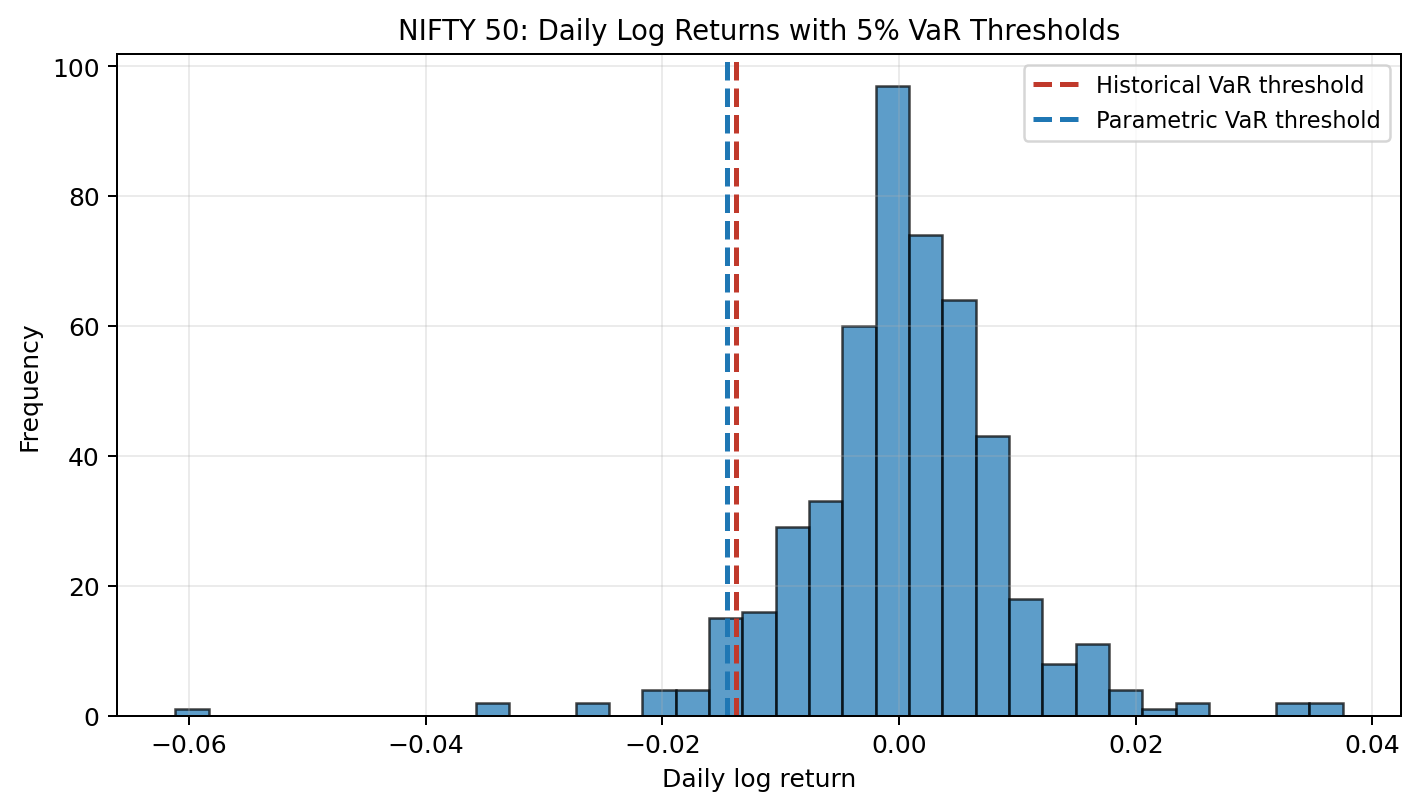

**Extreme tail observations: worst 5 daily log returns**

,Price,Log Return
Date,,
2024-06-04,21884.50,-0.06112
2026-03-19,23002.15,-0.03316
2025-04-07,22161.60,-0.03297
2024-08-05,24055.60,-0.02715
2026-03-23,22512.65,-0.02638


**Metric summary**

,Historical VaR,Historical CVaR,Parametric VaR,Parametric CVaR,Historical Tail Gap,Parametric Tail Gap,Historical Tail Amplification,Parametric Tail Amplification
Asset,,,,,,,,
NIFTY 50,0.01373,0.02045,0.01452,0.01826,0.00672,0.00374,1.48928,1.25742



**Observations for NIFTY 50**

- The 5% historical loss threshold is about 0.0137, so the return-space cutoff is -0.0137.
- Historical CVaR is 0.0205, which estimates the average loss after crossing that cutoff.
- The historical tail is heavier than the Gaussian tail based on CVaR (0.0205 vs 0.0183).
- Historical tail amplification is 1.49x, meaning CVaR is that multiple of historical VaR.


In [67]:
run_asset_block("NIFTY 50")

### HUL

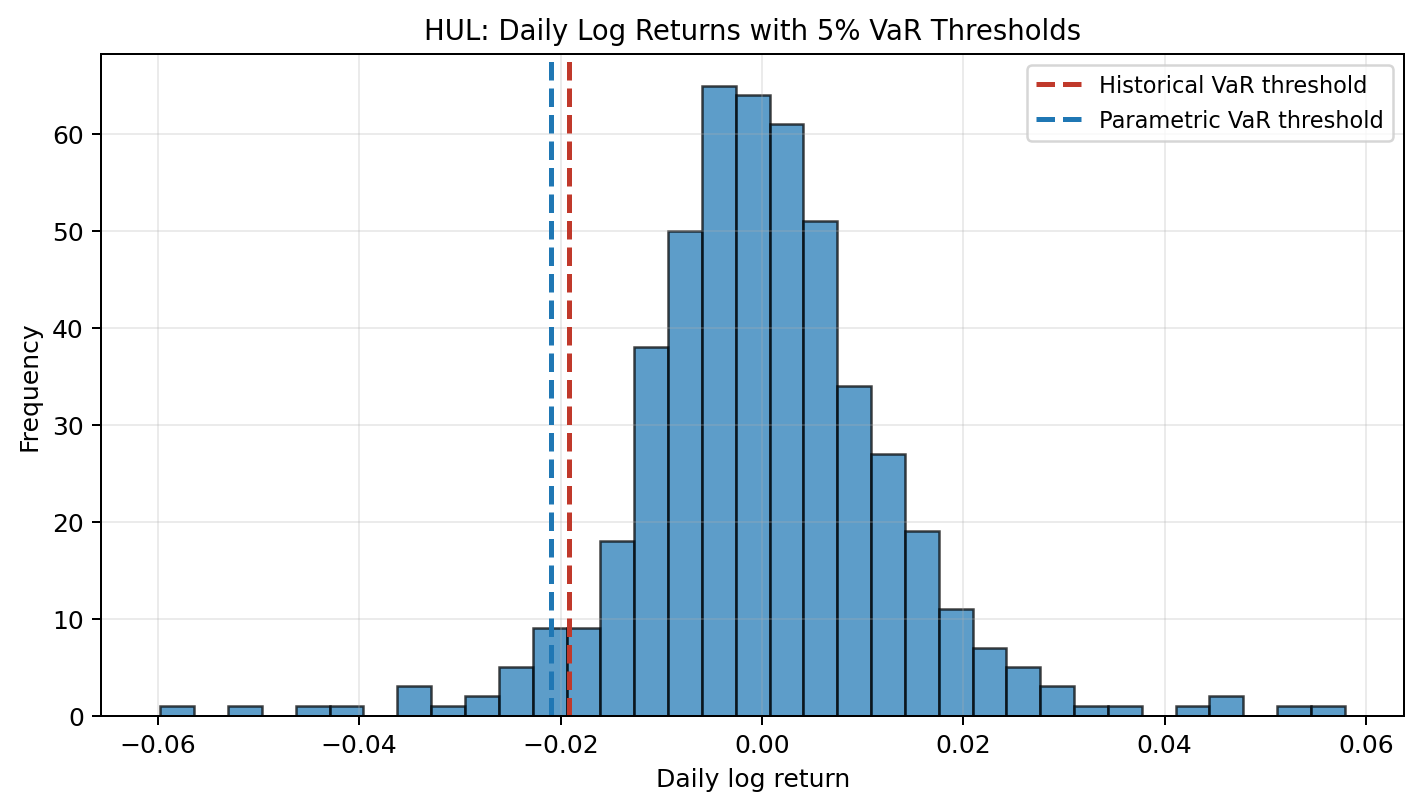

**Extreme tail observations: worst 5 daily log returns**

,Price,Log Return
Date,,
2024-10-24,2431.40,-0.05973
2025-12-05,2338.60,-0.05150
2026-02-13,2305.20,-0.04433
2025-04-24,2283.15,-0.04149
2025-01-14,2325.03,-0.03447


**Metric summary**

,Historical VaR,Historical CVaR,Parametric VaR,Parametric CVaR,Historical Tail Gap,Parametric Tail Gap,Historical Tail Amplification,Parametric Tail Amplification
Asset,,,,,,,,
HUL,0.01917,0.02860,0.02090,0.02623,0.00943,0.00533,1.49192,1.25512



**Observations for HUL**

- The 5% historical loss threshold is about 0.0192, so the return-space cutoff is -0.0192.
- Historical CVaR is 0.0286, which estimates the average loss after crossing that cutoff.
- The historical tail is heavier than the Gaussian tail based on CVaR (0.0286 vs 0.0262).
- Historical tail amplification is 1.49x, meaning CVaR is that multiple of historical VaR.


In [68]:
run_asset_block("HUL")

### Adani Enterprises

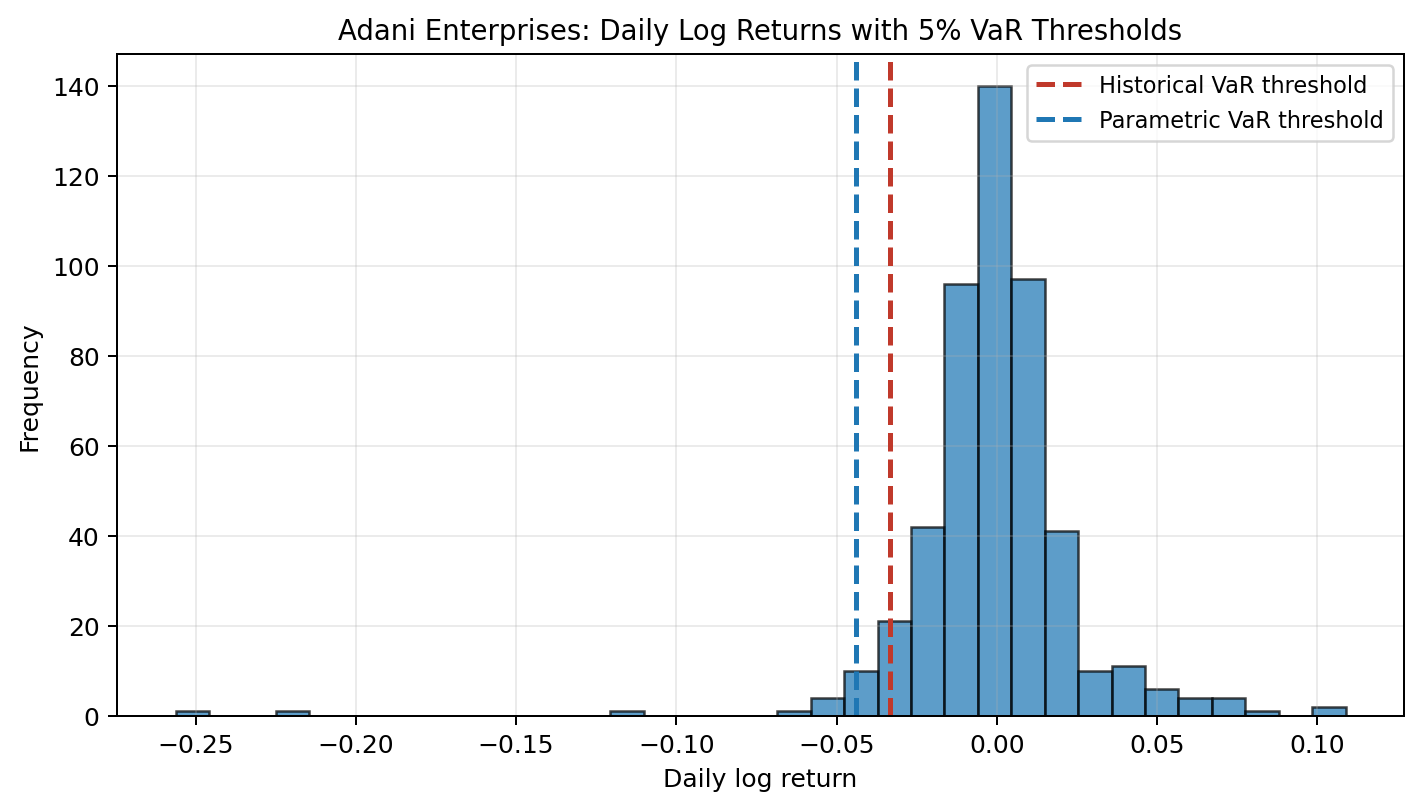

**Extreme tail observations: worst 5 daily log returns**

,Price,Log Return
Date,,
2024-11-21,2182.57,-0.25627
2024-06-04,2938.64,-0.21459
2026-01-23,1864.20,-0.11261
2025-01-13,2224.05,-0.06492
2025-04-07,2211.60,-0.05365


**Metric summary**

,Historical VaR,Historical CVaR,Parametric VaR,Parametric CVaR,Historical Tail Gap,Parametric Tail Gap,Historical Tail Amplification,Parametric Tail Amplification
Asset,,,,,,,,
Adani Enterprises,0.03338,0.06056,0.04403,0.05506,0.02718,0.01103,1.81422,1.25041



**Observations for Adani Enterprises**

- The 5% historical loss threshold is about 0.0334, so the return-space cutoff is -0.0334.
- Historical CVaR is 0.0606, which estimates the average loss after crossing that cutoff.
- The historical tail is heavier than the Gaussian tail based on CVaR (0.0606 vs 0.0551).
- Historical tail amplification is 1.81x, meaning CVaR is that multiple of historical VaR.


In [69]:
run_asset_block("Adani Enterprises")

## Cross-asset comparison

These plots compare the risk levels, the extra loss beyond VaR, and the amplification from VaR to CVaR across the three assets.

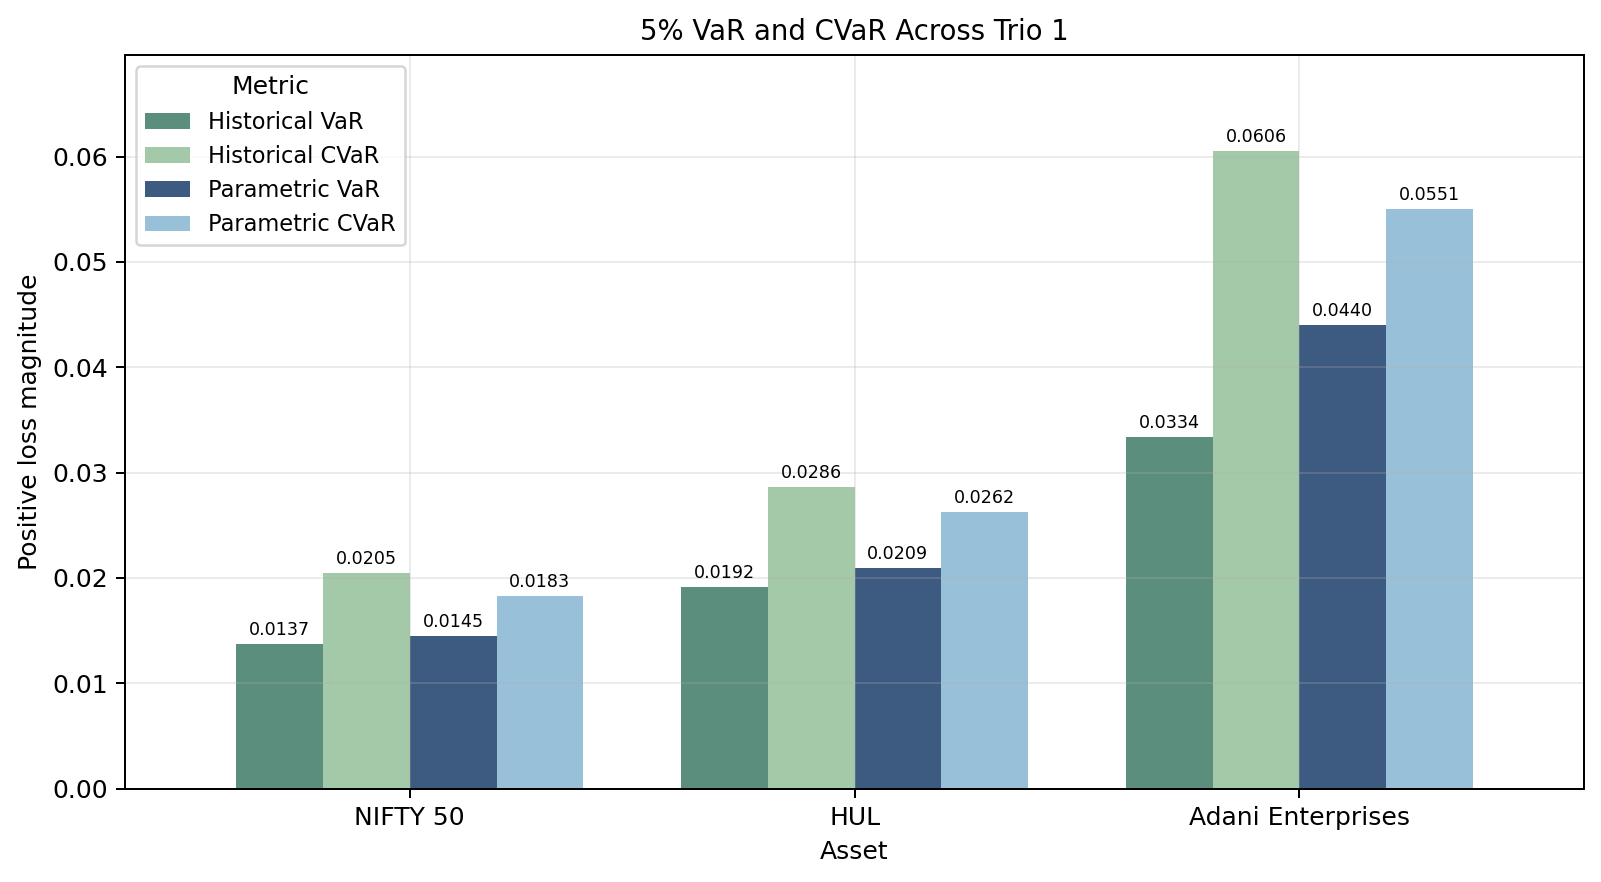

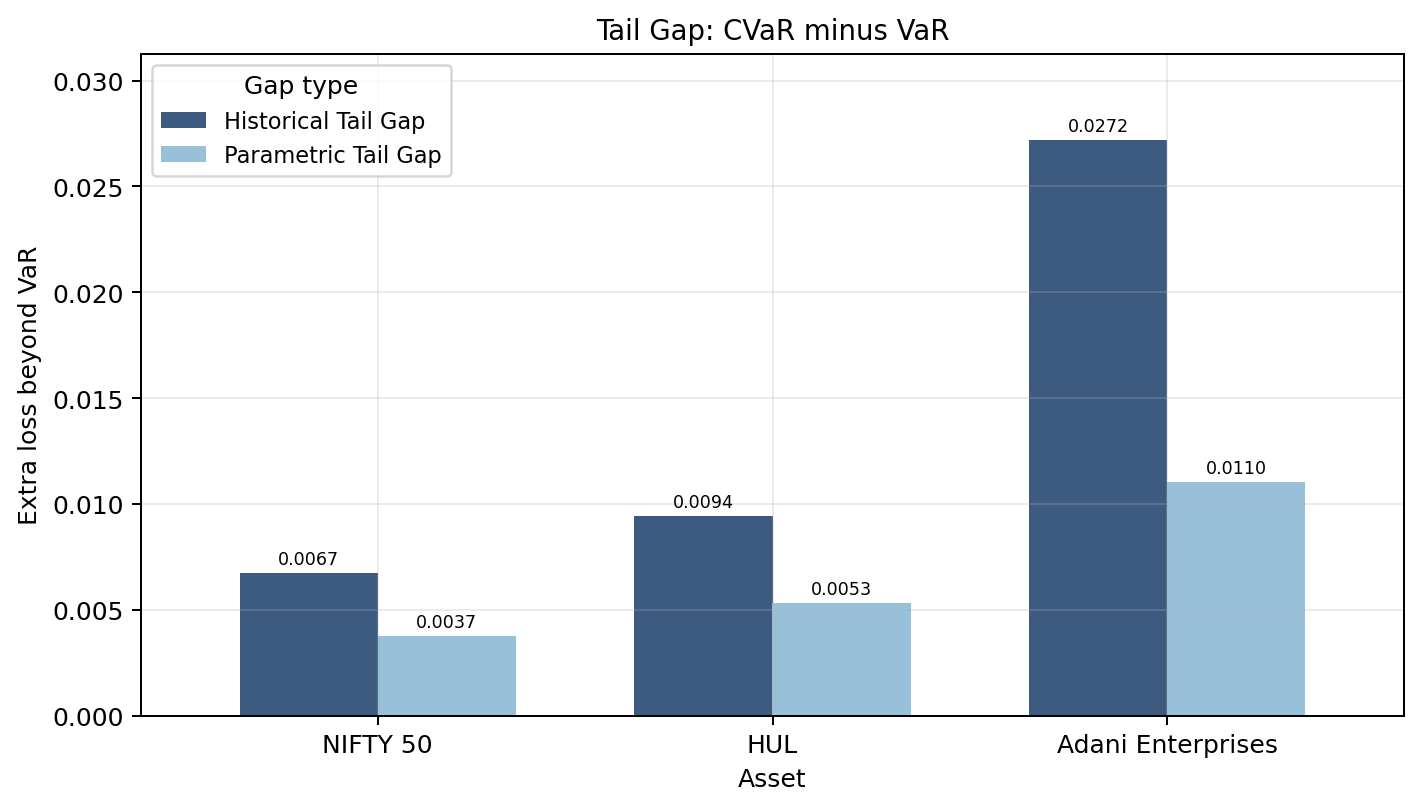

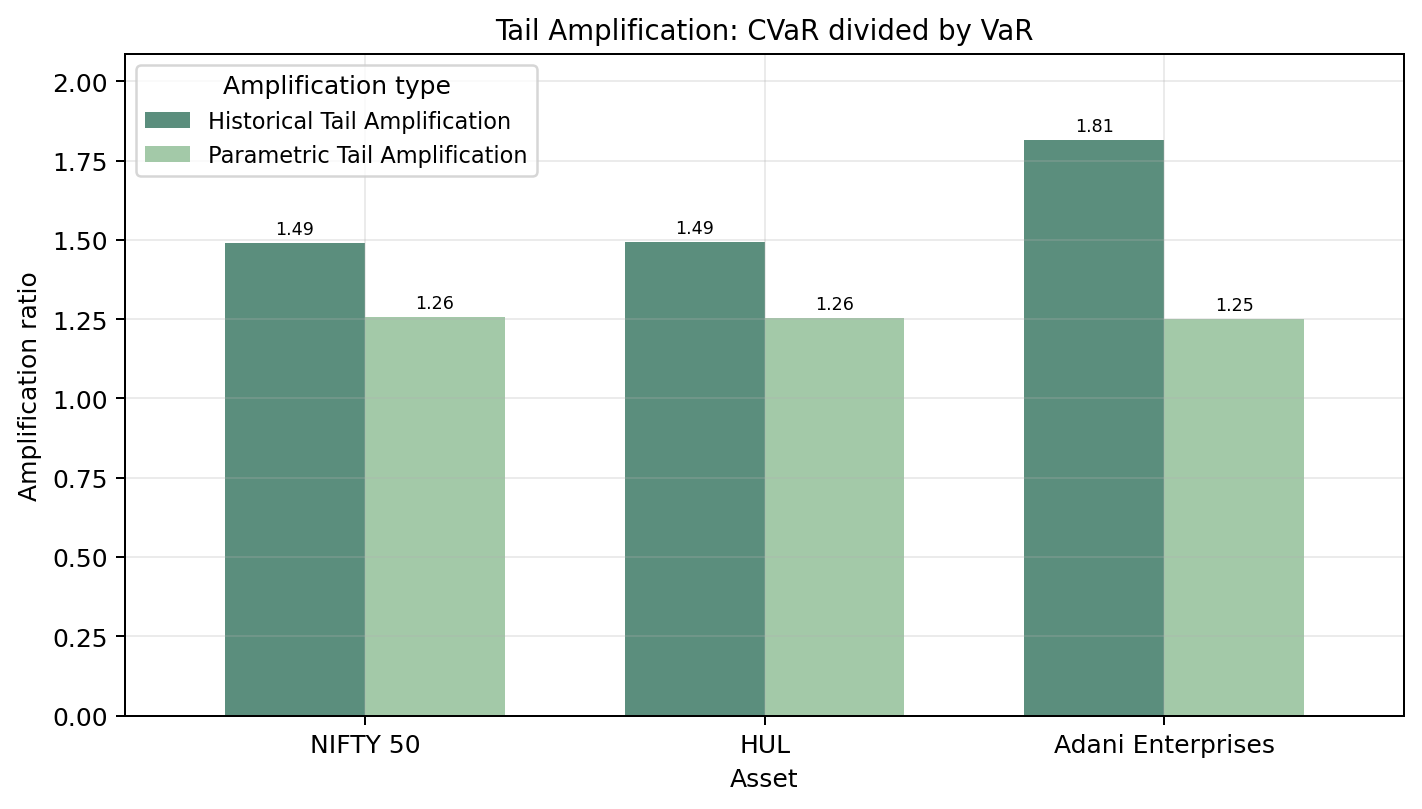

In [70]:
def add_bar_labels(ax, fmt="{:.4f}"):
    for container in ax.containers:
        labels = [fmt.format(value) for value in container.datavalues]
        ax.bar_label(container, labels=labels, padding=2, fontsize=7)
    ax.margins(y=0.15)


risk_cols = ["Historical VaR", "Historical CVaR", "Parametric VaR", "Parametric CVaR"]
risk_color = ["#5B8E7D", "#A3C9A8", "#3D5A80", "#98C1D9"]
ax = risk_table[risk_cols].plot(kind="bar", figsize=(9, 5), width=0.78, color=risk_color)

ax.set_title("5% VaR and CVaR Across Trio 1")
ax.set_xlabel("Asset")
ax.set_ylabel("Positive loss magnitude")
ax.legend(title="Metric")
add_bar_labels(ax, "{:.4f}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gap_cols = ["Historical Tail Gap", "Parametric Tail Gap"]
ax = risk_table[gap_cols].plot(kind="bar", figsize=(8, 4.6), width=0.7, color=risk_color[2:])
ax.set_title("Tail Gap: CVaR minus VaR")
ax.set_xlabel("Asset")
ax.set_ylabel("Extra loss beyond VaR")
ax.legend(title="Gap type")
add_bar_labels(ax, "{:.4f}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

amp_cols = ["Historical Tail Amplification", "Parametric Tail Amplification"]
ax = risk_table[amp_cols].plot(kind="bar", figsize=(8, 4.6), width=0.7, color = risk_color)
ax.set_title("Tail Amplification: CVaR divided by VaR")
ax.set_xlabel("Asset")
ax.set_ylabel("Amplification ratio")
ax.legend(title="Amplification type")
add_bar_labels(ax, "{:.2f}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/var/folders/r4/6gw7r2mj0t5g7qss7k7160940000gn/T/ipykernel_72632/931813379.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(return_values, labels=list(asset_files.keys()), showfliers=True)


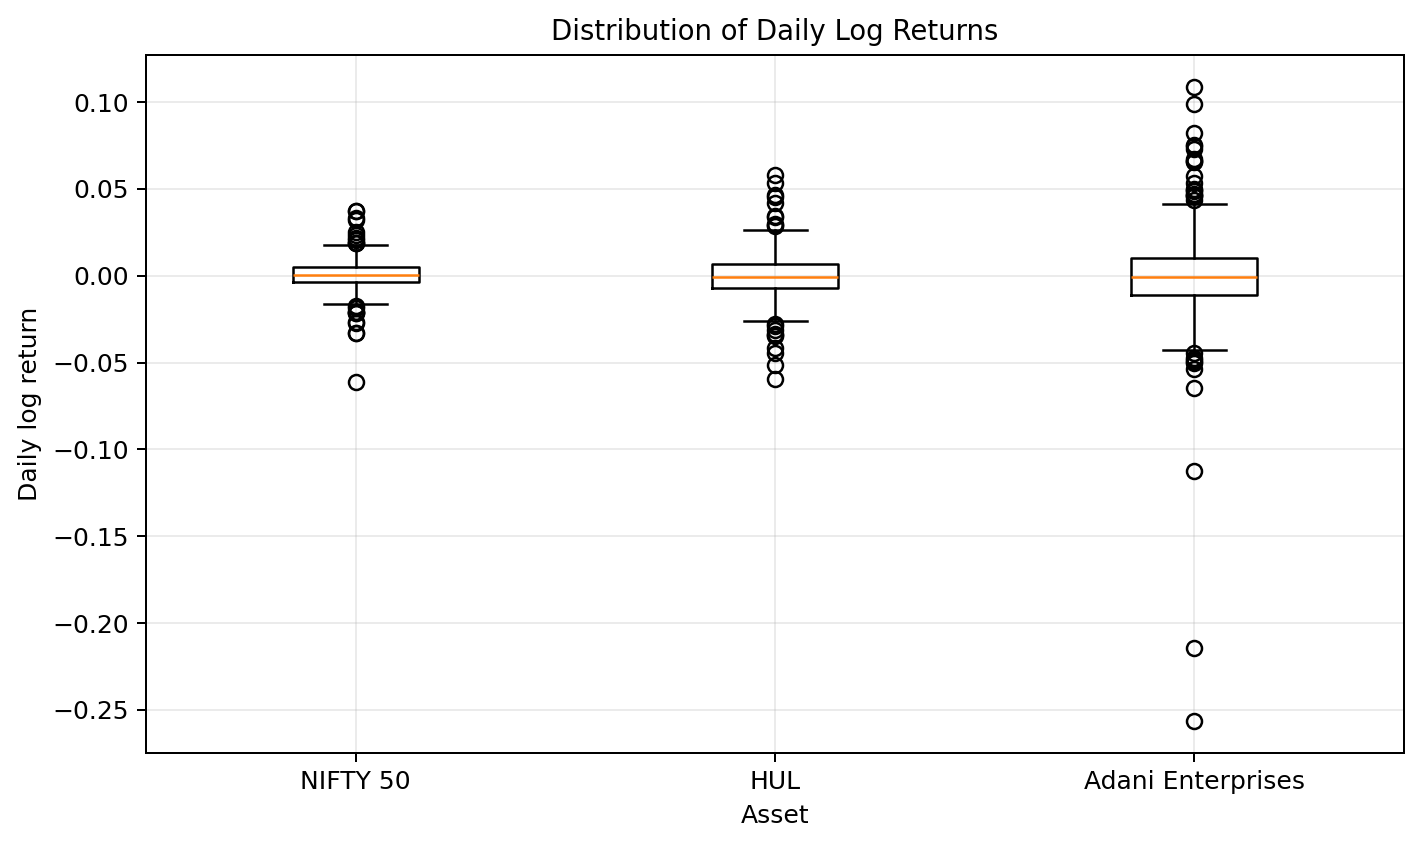

In [71]:
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=180)
return_values = [returns[asset].dropna().values for asset in asset_files.keys()]
ax.boxplot(return_values, labels=list(asset_files.keys()), showfliers=True)
ax.set_title("Distribution of Daily Log Returns")
ax.set_xlabel("Asset")
ax.set_ylabel("Daily log return")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cross-asset interpretation

The comments below are generated after the tables are calculated, so they reflect the actual loaded data.

In [72]:
def comparison_interpretation():
    highest_var = risk_table["Historical VaR"].idxmax()
    highest_cvar = risk_table["Historical CVaR"].idxmax()
    highest_amp = risk_table["Historical Tail Amplification"].idxmax()
    biggest_method_gap = (risk_table["Historical CVaR"] - risk_table["Parametric CVaR"]).abs().idxmax()

    index_var = risk_table.loc["NIFTY 50", "Historical VaR"]
    stock_avg_var = risk_table.loc[["HUL", "Adani Enterprises"], "Historical VaR"].mean()
    index_text = "lower" if index_var < stock_avg_var else "not lower"

    hul_var = risk_table.loc["HUL", "Historical VaR"]
    adani_var = risk_table.loc["Adani Enterprises", "Historical VaR"]
    hul_text = "more defensive" if hul_var < adani_var else "not more defensive"

    text = f"""
- {highest_var} has the highest 5% historical VaR, so it has the highest threshold risk in this trio.
- {highest_cvar} has the highest historical CVaR, so its losses beyond the threshold are most severe on average.
- {highest_amp} has the largest historical tail amplification ratio.
- The NIFTY 50 shows {index_text} downside threshold risk than the average of the two individual stocks in this sample.
- HUL behaves {hul_text} than Adani Enterprises based on historical VaR.
- Historical and parametric CVaR differ most for {biggest_method_gap}, which is where the Gaussian assumption needs the most caution.
- Overall, the trio design helps compare a diversified benchmark, a defensive large-cap stock, and a more volatile stock in the same tail-risk framework.
"""
    return Markdown(text)


display(comparison_interpretation())


- Adani Enterprises has the highest 5% historical VaR, so it has the highest threshold risk in this trio.
- Adani Enterprises has the highest historical CVaR, so its losses beyond the threshold are most severe on average.
- Adani Enterprises has the largest historical tail amplification ratio.
- The NIFTY 50 shows lower downside threshold risk than the average of the two individual stocks in this sample.
- HUL behaves more defensive than Adani Enterprises based on historical VaR.
- Historical and parametric CVaR differ most for Adani Enterprises, which is where the Gaussian assumption needs the most caution.
- Overall, the trio design helps compare a diversified benchmark, a defensive large-cap stock, and a more volatile stock in the same tail-risk framework.


## Conclusion

VaR identifies the cutoff for bad losses at the selected tail level. CVaR extends VaR by measuring the average severity beyond that cutoff.

The trio comparison helps show how downside risk differs between a diversified market index, a stable defensive stock, and a more volatile stock. Comparing historical and parametric results also helps check whether a Gaussian model is missing real tail behavior.

## Key Findings

These bullet points are generated from the computed results.

In [73]:
def key_findings():
    highest_var = risk_table["Historical VaR"].idxmax()
    lowest_var = risk_table["Historical VaR"].idxmin()
    highest_cvar = risk_table["Historical CVaR"].idxmax()
    highest_gap = risk_table["Historical Tail Gap"].idxmax()
    highest_amp = risk_table["Historical Tail Amplification"].idxmax()
    highest_vol = descriptive_table["Std Dev"].idxmax()
    biggest_param_diff = (risk_table["Historical VaR"] - risk_table["Parametric VaR"]).abs().idxmax()

    text = f"""
- Highest historical VaR: {highest_var}.
- Lowest historical VaR: {lowest_var}.
- Highest historical CVaR: {highest_cvar}.
- Largest historical tail gap: {highest_gap}.
- Largest historical tail amplification: {highest_amp}.
- Highest daily return volatility: {highest_vol}.
- Largest historical vs parametric VaR difference: {biggest_param_diff}.
- CVaR is larger than VaR for each asset, so it gives a stricter view of extreme downside loss.
"""
    return Markdown(text)


display(key_findings())


- Highest historical VaR: Adani Enterprises.
- Lowest historical VaR: NIFTY 50.
- Highest historical CVaR: Adani Enterprises.
- Largest historical tail gap: Adani Enterprises.
- Largest historical tail amplification: Adani Enterprises.
- Highest daily return volatility: Adani Enterprises.
- Largest historical vs parametric VaR difference: Adani Enterprises.
- CVaR is larger than VaR for each asset, so it gives a stricter view of extreme downside loss.
